In [1]:
# Imports
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Global plot style
matplotlib.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 16,
    'axes.labelweight': 'medium',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

In [3]:
# Paths and output directory
DATA_PATH = "../1_data/processed/zone_sequence_merged.csv"
SAVE_DIR = "plots/eda_correlation"
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# Load merged dataset
climate_fire_df = pd.read_csv(DATA_PATH)
climate_fire_df["Date"] = pd.to_datetime(climate_fire_df["Date"])

zones = sorted(climate_fire_df["Zone_ID"].unique())
climate_features = ["Precipitation", "Humidity", "Temperature", "Wind"]

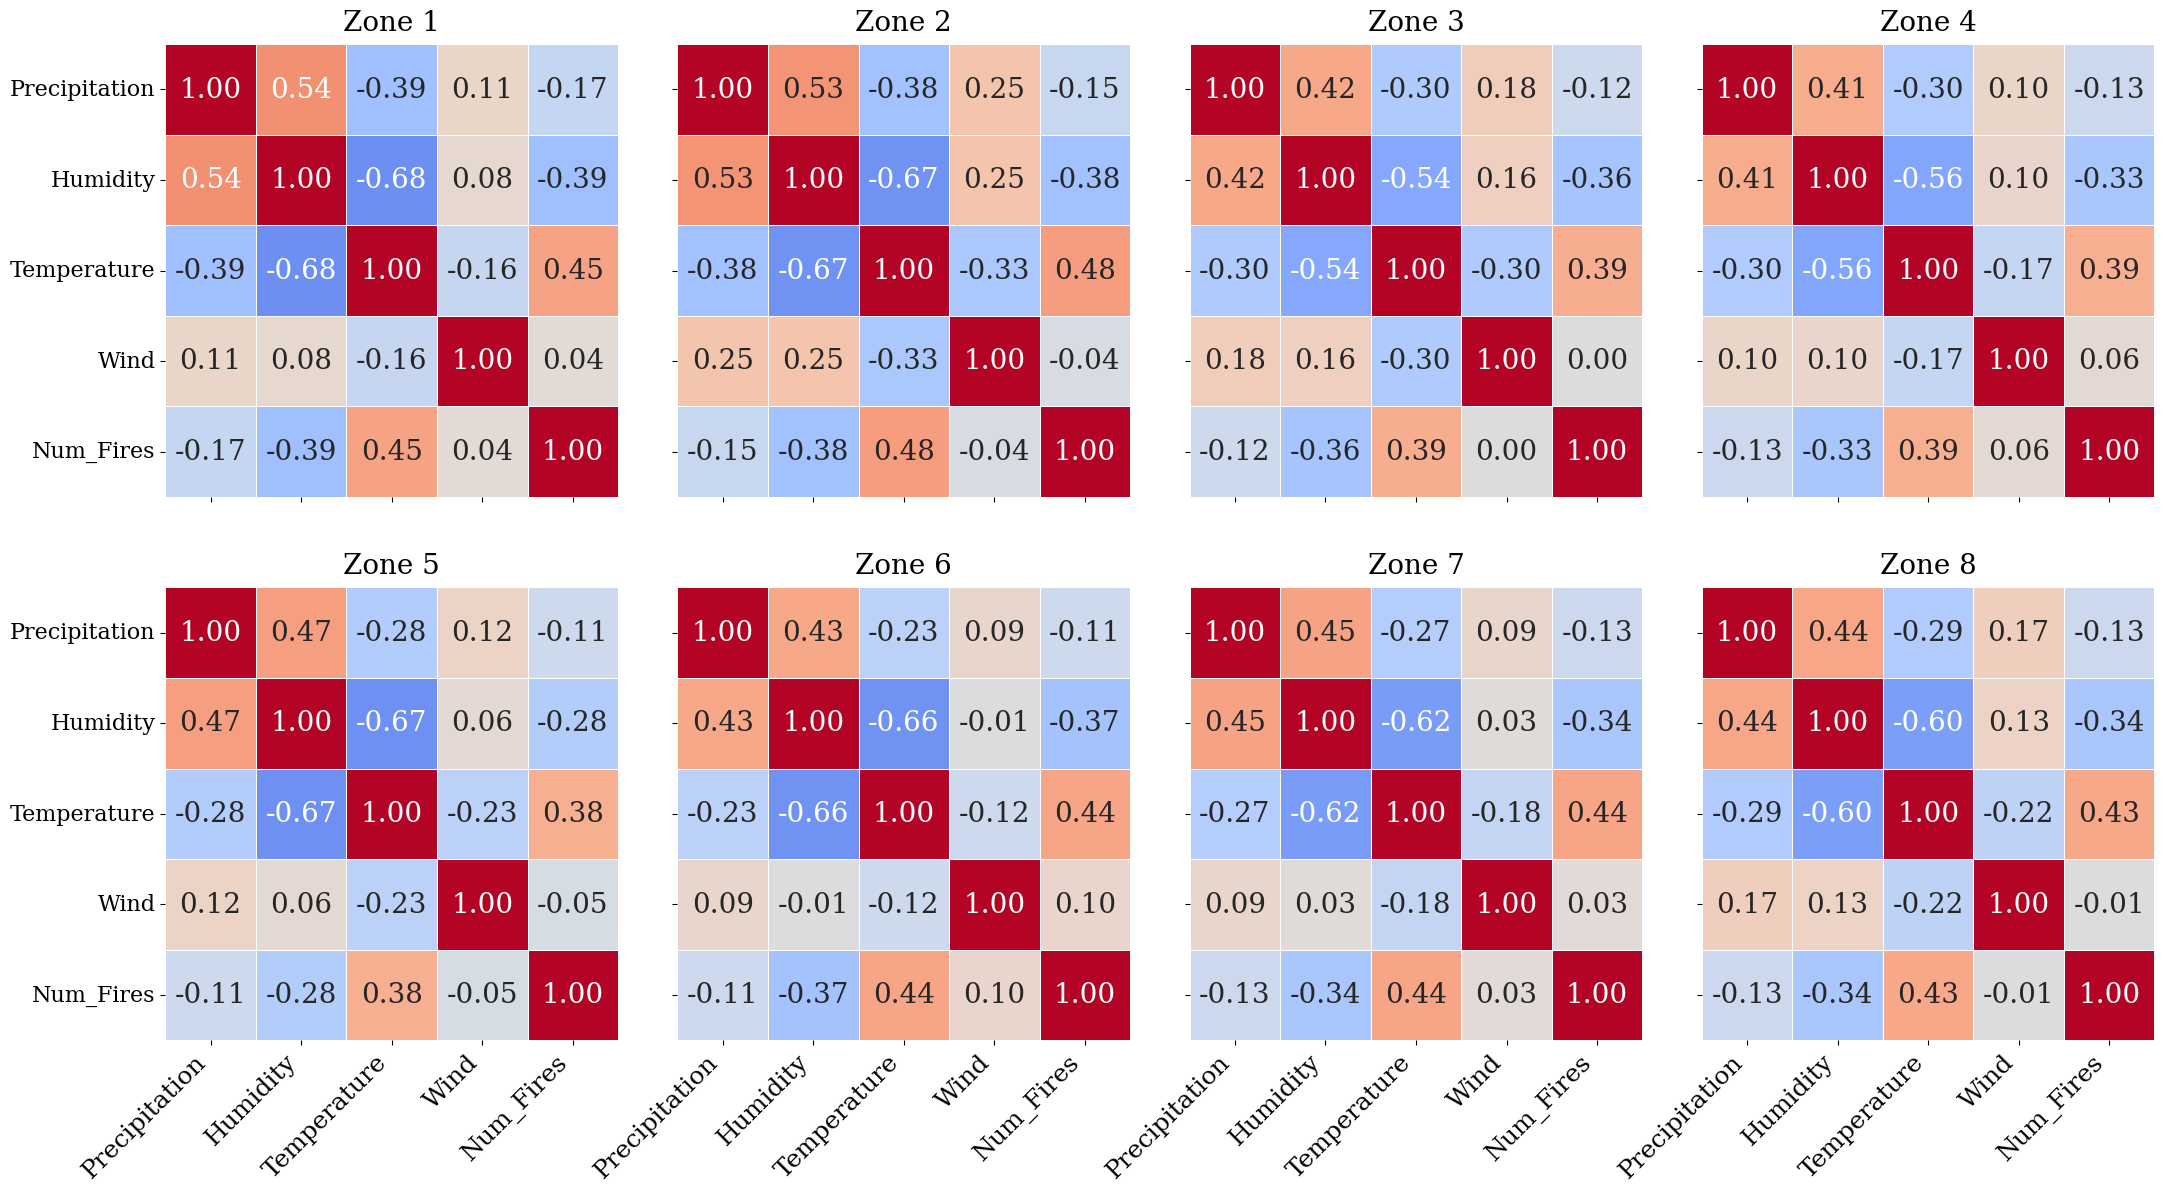

In [5]:
# Correlation heatmap per zone
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, zone in enumerate(zones):
    zone_df = climate_fire_df[climate_fire_df["Zone_ID"] == zone]
    corr = zone_df[climate_features + ["Num_Fires"]].corr()

    ax = axes[i]
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 20},
        cmap="coolwarm",
        vmin=-1, vmax=1,
        cbar=False,
        ax=ax,
        square=True,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(f"Zone {zone}", fontsize=20, pad=10)

    if i % 4 != 0:
        ax.set_yticklabels([])
    else:
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

    if i < 4:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=18)

plt.subplots_adjust(left=0.07, bottom=0.10, right=0.98, top=0.93, wspace=0.10, hspace=0.20)
plt.savefig(os.path.join(SAVE_DIR, "correlation_matrix_zones.png"), dpi=600, bbox_inches="tight")

In [6]:
# Compute same-day and lag-1 correlation per zone and save summary CSV
rows = []

for zone in zones:
    zone_df = climate_fire_df[climate_fire_df["Zone_ID"] == zone].copy()

    same_day_corr = zone_df[climate_features + ["Num_Fires"]].corr()["Num_Fires"].drop("Num_Fires")

    for feature in climate_features:
        zone_df[f"{feature}_lag1"] = zone_df[feature].shift(1)
    zone_df = zone_df.dropna(subset=[f"{f}_lag1" for f in climate_features] + ["Num_Fires"])

    lag_corr = zone_df[[f"{f}_lag1" for f in climate_features] + ["Num_Fires"]].corr()["Num_Fires"].drop("Num_Fires")
    lag_corr.index = climate_features

    for var in climate_features:
        rows.append({
            "Zone": zone,
            "Variable": var,
            "Same_Day_Corr": round(same_day_corr[var], 3),
            "Lag_1_Corr": round(lag_corr[var], 3)
        })

corr_df = pd.DataFrame(rows)
corr_df.to_csv(os.path.join(SAVE_DIR, "correlation_summary_zones.csv"), index=False)
print("Saved correlation summary")
corr_df

Saved correlation summary


,Zone,Variable,Same_Day_Corr,Lag_1_Corr
0,1,Precipitation,-0.167,-0.151
1,1,Humidity,-0.393,-0.370
2,1,Temperature,0.450,0.436
3,1,Wind,0.039,0.040
4,2,Precipitation,-0.151,-0.141
5,2,Humidity,-0.377,-0.333
6,2,Temperature,0.477,0.456
7,2,Wind,-0.044,-0.087
8,3,Precipitation,-0.116,-0.112
9,3,Humidity,-0.355,-0.299
